

# **A2.3 Modelos de ensamble, SVM y redes neuronales**




 De acuerdo con el INEGI, en 2024 29.6% de la población nacional (38.5 millones de personas) se encontraba en situación de pobreza multidimensional, mientras que 7 millones vivían en pobreza extrema. Estas cifras reflejan desigualdades estructurales que atraviesan comunidades enteras y condicionan su futuro. [1]

La base de datos empleada en este estudio proviene de la integración de fuentes oficiales, con variables socioeconómicas y de bienestar recopiladas del portal estatal del [INEGI](https://www.inegi.org.mx/app/estatal/). [2]

Se trata de la misma base de datos utilizada en el trabajo previo **“La deserción escolar: análisis de sus determinantes socioeconómicos”**, correspondiente al periodo 2020–2022.

Para la presente actividad se emplea la versión ya depurada del dataset, es decir, con el proceso de tratamiento y preparación de datos previamente realizado y utilizado en proyectos anteriores.

Teniendo como objetivo *entrenar y comparar distintos modelos avanzados de clasificación (basados en ensambles, márgenes máximos y redes neuronales) evaluando su desempeño en el mismo conjunto de datos* y reflexionando sobre las diferencias observadas en términos de capacidad predictiva, estabilidad y complejidad del modelo.










#### ***1. Análisis de datos***

Para dar inicio al análisis técnico, es necesario cargar la base de datos correspondiente **`Desercion_depurado.csv`**, previamente recopilada del portal de datos.

Una vez que el archivo se encuentra en la carpeta de trabajo, se importará la librería `pandas`, la cual permite la manipulación y análisis de datos estructurados. Posteriormente, mediante el uso de la función `read_cvs()`, se realiza la lectura del archivo, almacenándose en un objeto `data`, el cual contendrá información de las 32 entidades federativas.

Igualmente, es necesario revisar el contenido del presente archivo. Mediante la función `print()` se aplicará la función `head()` en la variable `data`, desplegando por default las primeras cinco filas de datos.

In [ ]:
import pandas as pd
data =pd.read_csv('Desercion_depurado.csv')
print(data.head())

               Entidad  Pobreza  Desocupacion  Serv_salud  Red_apoyo  \
0       Aguascalientes     23.7      0.841393    0.828106  -0.358725   
1      Baja California     13.4     -0.666383    0.651229   1.044288   
2  Baja California Sur     13.3     -0.127892    1.543654   2.166698   
3             Campeche     45.1     -0.450987    0.152757   0.687157   
4             Coahuila     18.2      1.272187    1.350697   0.304518   

   Desercion  Sat_vida  Homicidios_log  Pm25_log  Analfabeta_log  \
0  -0.839486  0.662298       -1.264057 -0.239899       -1.419899   
1   0.190994  1.220023        1.502265  1.114353       -0.519580   
2   1.043805  0.662298       -0.662096 -2.202820       -1.886686   
3   0.581866 -1.010876       -0.566276  0.703408       -0.800024   
4   0.759535  1.777748       -1.388012 -0.477491       -0.836208   

   No_electricidad_log  Viv_habitadas_log  
0            -1.853407          -1.095109  
1             0.483087           0.422794  
2            -0.862994    

De manera que, es posible observar que el conjunto de datos es adecuado para modelos de alta complejidad, dado que las variables ya presentan un escalado estándar, lo cual evita que variables con rangos mayores distorsionen los resultados.

A continuación, se describen las variables incluidas en el análisis: [3]


| Variable          | Descripción                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| **Entidad**       | Nombre oficial de la entidad federativa.                                    |
| **Pobreza**       | Porcentaje de la población en situación de pobreza.                         |
| **Pm25**          | Concentración promedio de partículas PM2.5 (µg/m³).                         |
| **Homicidios**    | Tasa de homicidios por cada 100 mil habitantes.                             |
| **Desocupacion**  | Tasa de desocupación (%).                                                   |
| **Serv_salud**    | Porcentaje de población con acceso a servicios de salud.                    |
| **Red_apoyo**     | Porcentaje de población que reporta contar con redes de apoyo.              |
| **Analfabeta_15** | Número de personas mayores de 15 años que no saben leer ni escribir.        |
| **No_electricidad** | Número de viviendas sin acceso a electricidad.                           |
| **Viv_habitadas** | Número total de viviendas habitadas en la entidad.                          |
| **Desercion**     | Porcentaje de deserción escolar.                                            |
| **Sat_vida**      | Nivel promedio de satisfacción con la vida.                                 |


Las variables expresadas en porcentaje representan proporciones relativas al total de viviendas de cada entidad federativa, lo cual permite comparabilidad territorial independientemente del tamaño poblacional.





#### ***1.1 Definición de variable de salida "Pobreza"***

En el presente análisis, la variable de salida seleccionada es `Pobreza`, que representa el porcentaje de población en situación de pobreza multidimensional en cada entidad federativa.

Para mantener la consistencia con los análisis previos y permitir una comparación directa, se utiliza la variable Pobreza binarizada. El criterio de clasificación se establece en un umbral del 40% de pobreza multidimensional, definiendo así dos clases:


* 1 = Alta pobreza (entidades con valores ≥ 40%)
* 0 = Baja pobreza (entidades con valores < 40%)

Para ello se creará una nueva variable binaria llamada `Pobreza_binaria`, a partir de la original `Pobreza`. Donde, se muestran las primeras filas `Entidad`, `Pobreza` con `.head()` y la nueva variable binarizada, para verificar que la transformación se realizó correctamente.


In [ ]:
import numpy as np

data['Pobreza_binaria'] = np.where(data['Pobreza'] >= 40, 1, 0)


print(data[['Entidad', 'Pobreza', 'Pobreza_binaria']].head())

               Entidad  Pobreza  Pobreza_binaria
0       Aguascalientes     23.7                0
1      Baja California     13.4                0
2  Baja California Sur     13.3                0
3             Campeche     45.1                1
4             Coahuila     18.2                0


La nueva variable de salida correponderá a **Pobreza_binaria**, la cual clasifica a las observaciones en dos categorías: **pobreza alta o pobreza baja**; permitiendo así adaptar el problema a un escenario de clasificación.

Cabe destacar que la selección de variables predictoras se basa en los resultados del análisis previo, donde se evaluaron de acuerdo a supuestos estadísticos.

 Por lo cual, los modelos actuales se entrenan utilizando únicamente el conjunto de variables: **No_electricidad_log, Pm25_log, Red_apoyo, Sat_vida y Homicidios_log**.




#### ***1.2 Partición de datos***

Tras seleccionar la variable de salida, *Pobreza_binaria*, con las clases pobreza alta y pobreza baja, es fundamental establecer un planteamiento que permita una comparación justa entre los modelos por implementar.

Tras haberse evaluado en trabajos previos el desempeño de distintas particiones, se optó por utilizar una división de entrenamiento y prueba de 70/30. Esta proporción demostró ser la más adecuada para mantener el balance de clases, garantizando la representatividad de las 32 entidades federativas.

Para ello, se empleará la función  `train_test_split` del módulo `sklearn.model_selection`, asegurando que las variables de prueba no se usaran durante el entrenamiento, evitando así la fuga de información.

In [ ]:
from sklearn.model_selection import train_test_split


X = data.drop(columns=[
    'Pobreza_binaria', 'Entidad', 'Pobreza',
    'Desocupacion', 'Desercion',
    'Analfabeta_log', 'Viv_habitadas_log',
    'Serv_salud'
])
y = data['Pobreza_binaria']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

s
print(f"Registros totales: {len(data)}")
print(f"Registros entrenamiento: {len(X_train)}")
print(f"Registros prueba: {len(X_test)}")

Registros totales: 32
Registros entrenamiento: 22
Registros prueba: 10


Tras realizar la partición 70/30, el conjunto de datos de 32 observaciones se divide en 22 para entrenamiento y las 10 restantes para prueba. Esto permite que los modelos tengan información suficiente para el aprendizaje, mientras se reserva un grupo de entidades para validar su capacidad predictiva.


### ***2. Construcción de modelos***

En esta sección, se entrenarán cuatro modelos con el objetivo de analizar cómo varía el desempeño y la estabilidad de las predicciones mediante distintos métodos sobre el mismo conjunto de datos depurado.

Entrenando y comparando modelos basados en ensambles, márgenes máximos y redes neuronales: **Random Forest, Boosting, Support Vector Machines (SVM) y una Red Neuronal sencilla.**







#### ***2.1 Modelo basado en Random Forest***

Primeramente, nos enfocaremos en **Random Forest**, algoritmo de aprendizaje por ensamble que se basa en la construcción de múltiples árboles de desición.[4]

Este método se basa en el Bagging, donde el modelo genera multiples subconjuntos de datos con muestras aleatorias con reemplazo del dataset original. Entrenando cada arbol con una perspectiva distinta de los datos, determinando la predicción final mediante el voto de la mayoría.[4]

Para ello se seleccionarán los siguientes hiperparámetros:

| Hiperparámetro | Configuración | Descripción y Justificación |
| :--- | :--- | :--- |
| **n_estimators** | 100 | Uso de 100 árboles para asegurar un modelo robusto dado que se trabaja con 32 entidades. |
| **max_features** | 'sqrt' | Considera la raíz cuadrada del total de variables en cada partición para aumentar la diversidad. |
| **max_depth** | 3 | Limita la profundidad para evitar el sobreajuste ante un set de entrenamiento pequeño (22 observaciones). |
| **random_state** | 42 | Garantiza la reproducibilidad de las muestras y la construcción del bosque. |


Para ello utilizaremos la función `RandomForestClassifier` con hiperparámetros definidos para así entrenarlo con `.fit(X_train, y_train)` usando los datos de entrenamiento, y así predecir con `.predict(X_test)` sobre los datos de prueba para evaluar su desempeño.




In [ ]:
from sklearn.ensemble import RandomForestClassifier


modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=3,
    random_state=42
)


modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("¡Modelo Random Forest entrenado exitosamente!")

¡Modelo Random Forest entrenado exitosamente!


Una vez que el modelo de Random Forest ha sido entrenado y sus predicciones han sido generadas bajo los parámetros establecidos, se procede con la construcción del siguiente modelo de ensamble.

#### ***2.2 Modelo basado en Boosting***

Por su parte, continuaremos con el método **Boosting**. En este método, los modelos se basan en la combinación secuencial de varios árboles de decisión débiles. Donde, se entrenan uno tras otro, donde cada clasificador busca corregir los errores cometidos por los modelos anteriores.[5]

Centrándose en ajustar los pesos de las observaciones clasificadas de manera incorrecta permitiendo que el modelo final sea la combinación de varios modelos que fueron depurados uno tras otro. [5]

Para ello se seleccionarán los siguientes hiperparámetros:

| Hiperparámetro | Configuración | Descripción y Justificación |
| :--- | :--- | :--- |
| **n_estimators** | 50 | Número equilibrado de estimadores para evitar que el modelo memorice el ruido del dataset pequeño (32 entidades). |
| **learning_rate** | 0.001 | Ritmo de aprendizaje bajo para que el modelo aprenda patrones, moviendose en pasos pequeños para evitar sobreajuste. |
| **random_state** | 42 | Asegura la reproducibilidad en la secuencia de corrección de errores. |

Para ello utilizaremos la función `AdaBoostClassifier` con hiperparámetros definidos para así entrenarlo con `.fit(X_train, y_train)` usando los datos de entrenamiento, y así predecir con `.predict(X_test)` sobre los datos de prueba para evaluar su desempeño.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

modelo_boost = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.001,
    random_state=42
)


modelo_boost.fit(X_train, y_train)
y_pred_boost = modelo_boost.predict(X_test)

print("¡Modelo AdaBoost entrenado exitosamente!")

¡Modelo AdaBoost entrenado exitosamente!


Una vez que el modelo basado en Boosting ha sido entrenado y sus predicciones han sido generadas bajo los parámetros establecidos, se procede con la construcción del siguiente modelo de ensamble.

#### ***2.3 Modelo basado Support Vector Machine***

Continuando con el modelo de **Máquina de Soporte Vectorial (SVM)**; se utilizará para la clasificación mediante un hiperplano en un espacio que clasifique los puntos de datos. [6]

Buscando encontrar el plano que tenga el margen máximo, es decir, la distancia máxima entre los puntos de datos de ambas clases. Siendo eficiente en conjuntos de datos donde las categorías están bien definidas pero el número de muestras es limitado. [6]

Para ello se seleccionarán los siguientes hiperparámetros:

| Hiperparámetro | Configuración | Descripción y Justificación |
| :--- | :--- | :--- |
| **Kernel** | 'linear' | Utilizaremos un núcleo lineal para evitar la complejidad que en este caso es innecesaria, dado que buscamos una separación directa entre las entidades. |
| **C** | 1.0 | El parámetro de regularización estándar manteniendo un márgen suave que indica una penalización moderada por errores. |
| **probability** | True | Permite que el modelo devuelva probabilidades, útil para el análisis de métricas de calidad. |
| **random_state** | 42 | Asegura que los resultados del algoritmo sean consistentes y reproducibles en cada ejecución. |

Para ello utilizaremos la función `SVC` con hiperparámetros tales como kernel en lineal y parámetro `C` definidos para así entrenarlo con `.fit(X_train, y_train)` usando los datos de entrenamiento, y así predecir con `.predict(X_test)` sobre los datos de prueba para evaluar su desempeño.


In [ ]:
from sklearn.svm import SVC


modelo_svm = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    random_state=42
)


modelo_svm.fit(X_train, y_train)
y_pred_svm = modelo_svm.predict(X_test)

print("¡Modelo SVM entrenado exitosamente!")


¡Modelo SVM entrenado exitosamente!


Una vez que el modelo basado en SVM ha sido entrenado y sus predicciones han sido generadas bajo los parámetros establecidos, se procede con la construcción del siguiente modelo de ensamble.

#### ***2.4 Modelo basado en Redes Neuronales***

Finalmente, se implementará una **Red Neuronal** sencilla. Este modelo se encuentra compuesto de capas de nodos: una capa de entreda, capas ocultas y una capa de salida. Donde, cada nodo se conecta con otros, contando con un peso y umbral asociado. De manera que, si la salida de un nodo supera el umbral, se activa y envía datos a la siguiente capa. [7]

De manera que, buscamos que la red aprenda las relaciones entre los indicadores socieconómicos y la pobreza en México. Donde, con contar con un dataset con pocas observaciones, se utilizará una estructura con el objetivo que el modelo sea capaz de generalizar sin memorizar los datos de entrenamiento (sobreajuste). [7]

Para ello se seleccionarán los siguientes hiperparámetros:

| Hiperparámetro | Configuración | Descripción y Justificación |
| :--- | :--- | :--- |
| **hidden_layer_sizes** | (2,) | Se utilizarán 2 neuronas para forzar a la red a sintetizar la información y evitar que memorice ruido del dataset. |
| **activation** | 'relu' | Función de activación estándar que permite gestionar la no linealidad sin añadir complejidad. |
| **solver** | 'lbfgs' | Algoritmo de optimización de memoria limitada para lograr estabilidad en muestras pequeñas. |
| **max_iter** | 1000 | Mantiene un límite amplio de iteraciones para garantizar que el modelo encuentre el punto óptimo de convergencia. |
| **random_state** | 42 | Asegura que la inicialización aleatoria de los pesos sea siempre la misma, permitiendo resultados reproducibles. |



Para ello utilizaremos la función `MLPClassifier` con hiperparámetros para así entrenarlo con `.fit(X_train, y_train)` usando los datos de entrenamiento, y así predecir con `.predict(X_test)` sobre los datos de prueba para evaluar su desempeño.



In [ ]:
from sklearn.neural_network import MLPClassifier


modelo_nn = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='relu',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)


modelo_nn.fit(X_train, y_train)
y_pred_nn = modelo_nn.predict(X_test)

print("¡Red Neuronal entrenada exitosamente!")

¡Red Neuronal entrenada exitosamente!


Una vez que el la red neuronal ha sido entrenada y sus predicciones han sido generadas bajo los parámetros establecidos, se procede con la etapa de evaluación experimental.

### ***3. Evaluación y comparación de desempeño***

En esta sección, se calcularán las métricas de desempeño (Accuracy, Precision, Recall y F1-Score) para cada modelo, con el fin de realizar un análisis comparativo que permita identificar cuál de ellos presenta la mejor capacidad predictiva y el menor error para identificar los casos de probreza y no pobreza sobre el conjunto de prueba.

Para ello se utilizarán las métricas tales como `accuracy_score`, `recall_score`, `precision_score`, `f1_score` para verificar la confiabilidad de la metodología utilizada, y finalmente organizar los resultados en un `DataFrame`.




In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


modelos = [modelo_rf, modelo_boost, modelo_svm, modelo_nn]
nombres = ['Random Forest', 'AdaBoost', 'SVM', 'Red Neuronal']


resultados = []

for i, modelo in enumerate(modelos):

    preds = [y_pred_rf, y_pred_boost, y_pred_svm, y_pred_nn][i]


    resultados.append({
        'Modelo': nombres[i],
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0)
    })


df_metricas = pd.DataFrame(resultados)
print("Comparativa de Desempeño:")
display(df_metricas)

Comparativa de Desempeño:


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8,0.666667,1.00,0.800000
1,AdaBoost,0.6,0.500000,0.50,0.500000
2,SVM,0.7,0.600000,0.75,0.666667
3,Red Neuronal,0.7,0.600000,0.75,0.666667


Al analizar los resultados obtenidos, es posible observar el desempeño del modelo Random Forest, el cual alcanzó una sensibilidad de 1.00, indicando una excelente capacidad de identificar todos los casos de pobreza alta en el conjunto de validación.

Mientras que, modelos como el SVM y la Red Neuronal mostraron resultados iguales con un exactitud De 0.70 y un F1-Score de 0.66, indicando que ambos fueron capaces de capturar tendencias simulares. Concluyendo con el modelo Boosting, mostrando las métricas más bajas, con valores de 0.50 en presición y sensibilidad, demostrando un dificultad para clasificar correctamente las distintas clases.

Por lo cual, con el objetivo de analizar más a detalle los resultados de los distintos modelos, se realizará una matriz de confusión para cada uno de los modelos entrenados. Permitiendo identificar la frecuencia de los falsos positivos y falsos negativos en la clasificación de la pobreza.

Donde, con la función `confusion_matrix` se compararon las etiquetas reales con las predichas, mientras que `ConfusionMatrixDisplay` mostrará la capacidad de distinción del modelo.

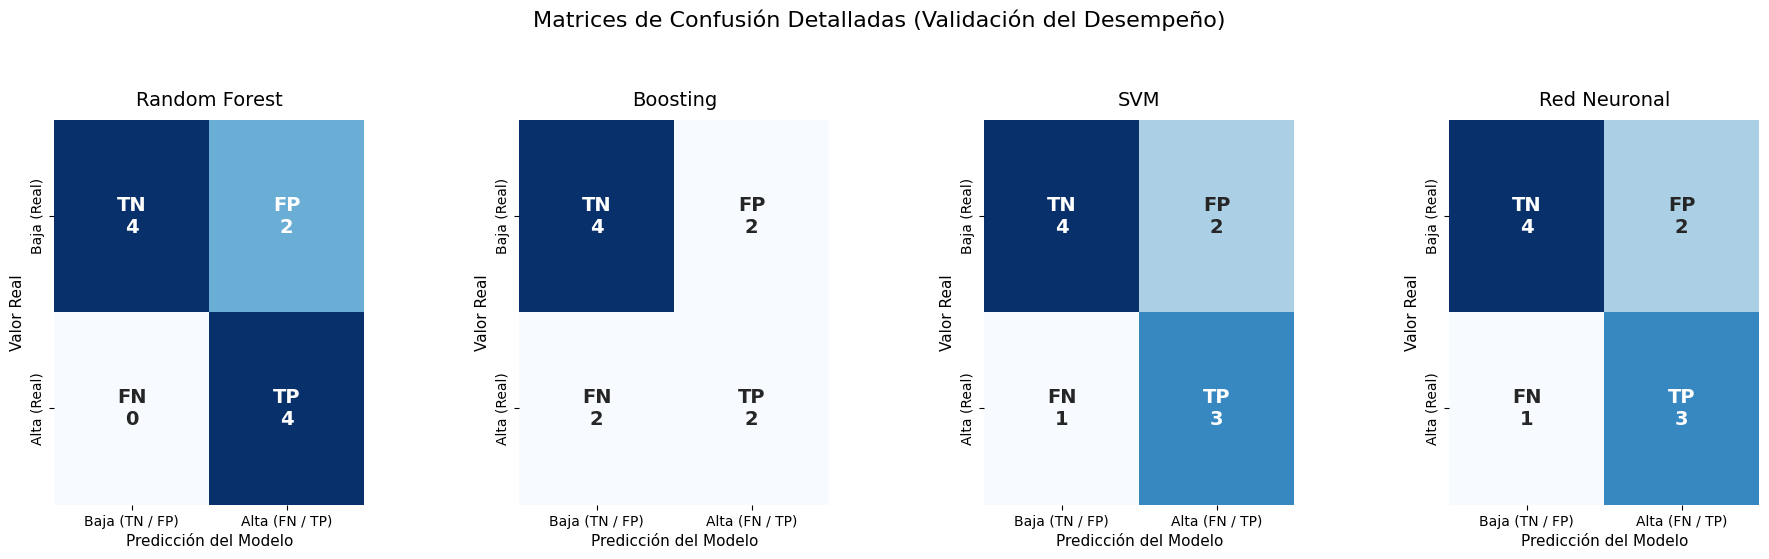

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


modelos = {
    'Random Forest': y_pred_rf,
    'Boosting': y_pred_boost,
    'SVM': y_pred_svm,
    'Red Neuronal': y_pred_nn
}

x_labels = ['Baja (TN / FP)', 'Alta (FN / TP)']
y_labels = ['Baja (Real)', 'Alta (Real)']


fig, axes = plt.subplots(1, 4, figsize=(22, 5))
plt.subplots_adjust(wspace=0.5)

for i, (nombre_modelo, y_pred) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, y_pred)


    group_names = ['TN','FP','FN','TP']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=x_labels, yticklabels=y_labels, ax=axes[i],
                annot_kws={"size": 14, "weight": "bold"})

    axes[i].set_title(f'{nombre_modelo}', fontsize=14, pad=10)
    axes[i].set_xlabel('Predicción del Modelo', fontsize=11)
    axes[i].set_ylabel('Valor Real', fontsize=11)

plt.suptitle('Matrices de Confusión (Validación del Desempeño)', fontsize=16, y=1.1)
plt.show()

Así, tras un análisis detallado, es posible determinar que **el modelo de Random Forest representa el mejor desempeño para la clasificación de niveles de pobreza**. Basándose principalmente en su capacidad de detección, destacando el valor de 0 Falsos Negativos (FN), reflejándose en la sensibilidad de 1.00 con una excelente capacidad de identificar todos los casos de "Pobreza Alta" en el conjunto de prueba.

Mientras que el SVM y la Red Neuronal presentaron 1 falso negativo, el modelo de Boosting fue el menos efectivo con 2 falsos negativos.

Observándose diferencias sustanciales en el desempeño, no meramente marginales; ya que mientras que el Random Foresta alcanza una exactitud de 0.80, el modelo de Boosting cae hasta un un 0.60, una diferencia del 20% que en un dataset pequeño como el utilizado, representa una diferencia crítica en la confiabilidad de predicciones. Viendose de igual forma con el SVM y la Red Neuronal, quedando ambos por debajo de el desempeño del Random Forest.

Permitiendonos analizar una relación entre la complejidad y el desempeño del experimento. Donde, Random Forest, siendo un modelo más complejo que SVM, demostró un mejor manejo de ruido presente en indicadores seleccionados. Sin embargo, aunque las redes neuronales son en teoría son más complejas y potentes, en un escenario con observaciones limitadas, no logró superar el Random Forest. Indicando que dicha complejidad no garantiza mejores resultados si la cantidad de datos no es suficiente para dicha estructura.

Determinando así que, las configuraciones conservadoras necesarias para evitar el sobreajuste limitó la capacidad de aprendizaje de los modelos, situándolos por detrás de modelos más directos, tal como se observa en el caso del Random Forest ante el Boosting o las Redes Neuronales.

### ***4. Análisis crítico y conclusiones***


Tras el análisis previo, se presentará una reflexión sobre la relación entre la capacidad de los modelos y su comportamiento ante un conjunto de datos pequeño.

Viéndose en los resultados que, el aumento de complejidad no indico necesariamente una mejora en los resultados. Pues, al trabajar con un dataset de pocas observaciones modelos complejos como las Redes Neuronales, quedaron por detrás de Random Forest.

Destacando, el sobreajuste como principal riesgo. Donde, para controlarlo se utilizaron hiperparámetros conservadores, tal como como limitar la Red Neuronal a 2 neuronas. Puesto que, a pesar de que aumentar la complejidad de la red permitía igualar las métricas del Random Forest, se busca priorizar la generalización sobre resultados por memorización. Buscando más allá de métricas perfectas, sino garantizar que el modelo funcione con datos nuevos y no solo con los actuales.


#### ***4.1 Interpretabilidad de modelos***

Asimismo, cada modelo ofrece un enfoque diferente que determina su utilidad o aplicación, no respondiendo a un ganador absoluto.

Mientras que el Random Forest destaca por su capacidad de generalizar y equilibrio al identificar patrones, el SVM se prefiere en contextos que exigen una frontera de decisión clara. Por otro lado, aunque la Red Neuronal y el Boosting ofrecen un potencial superior para procesar grandes conjuntos de datos complejos, en este estudio su interpretabilidad se mantiene baja.

En conclusión, no se establece un ganador absoluto porque cada modelo tiene fortalezas distintas según lo que se necesite; sin embargo, en términos de resultados predictivos, el Random Forest tuvo el mejor desempeño al identificar todos los casos de pobreza alta, mostrando una mayor estabilidad frente al sobreajuste.




### ***5. Referencias***

1. admin, “En México, más de 46 millones de personas viven en situación de pobreza,” Gaceta UNAM, Sep. 09, 2024. https://www.gaceta.unam.mx/en-mexico-mas-de-46-millones-de-personas-viven-en-situacion-de-pobreza/
‌
2. “Banco de Indicadores - Indicadores por entidad federativa,” www.inegi.org.mx. https://www.inegi.org.mx/app/estatal/

3. “POBREZA MULTIDIMENSIONAL,” INEGI. https://www.inegi.org.mx/contenidos/saladeprensa/boletines/2025/pm/pm2025_08.pdf
‌
4. IBM, “Random Forest,” Ibm.com, Oct. 20, 2021. https://www.ibm.com/mx-es/think/topics/random-forest

5. IBM, “Boosting,” Ibm.com, Sep. 28, 2021. https://www.ibm.com/mx-es/think/topics/boosting.

6. IBM, “Máquina de vector de soporte,” Ibm.com, Dec. 12, 2023. https://www.ibm.com/mx-es/think/topics/support-vector-machine

7. IBM, “Red neuronal,” Ibm.com, Oct. 06, 2021. https://www.ibm.com/mx-es/think/topics/neural-networks
‌
‌


‌
‌



El desarrollo de los bloques de código y la optimización de las funciones presentadas en este reporte contaron con el apoyo de herramientas de inteligencia artificial.